# MDR-TS v20.5
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v20.5
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**
- Classifier + Hard Gating to route the data

## 0. Imports

In [6]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier

import torch

import statsmodels.api as sm
import statsmodels.stats.api as sms

project_root = os.path.abspath("../../")
print(f"project root: {project_root}")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

project root: C:\Users\pan\Documents\GitHub\MDR-Project
imports loaded
using: cpu


In [7]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.12.8
  NumPy version:  2.4.4
  Pandas version: 3.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [ ]:
VERSION = "v20"
SUBVERSION = "v20.5"
RUN_NAME = "mdr_ts_v20_5"

PROJECT_ROOT = os.path.abspath("../../")  # this is relative to where the jupyter kernel is running, which is in Models/Temporal
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: C:\Users\pan\Documents\GitHub\MDR-Project
  DATA_ROOT:    C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data
  SPLIT_ROOT:   C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  C:\Users\pan\Documents\GitHub\MDR-Project/Models/Temporal/v20/v20.5

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [15]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\train.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\val.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\test.csv


In [16]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [17]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS_BASE = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",

    "A_d_E_SAR_diff_kobs14",

    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",

    "V_rollmean_s2_b11_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "V_rollmean_s2_b11_kobs7",

    "year_frac", "sin_year", "cos_year",
]

FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",

    "slope", "elev",
]

def _check_cols(df, cols, name):
    missing = sorted(set(cols) - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

for _df_name, _df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    _check_cols(_df, KEEP_META_COLS + [TARGET_COL], _df_name)
    _check_cols(_df, FEATURE_COLS_BASE, f"{_df_name} (BASE)")
    _check_cols(_df, FEATURE_COLS_DRY, f"{_df_name} (DRY)")
    _check_cols(_df, FEATURE_COLS_WET, f"{_df_name} (WET)")

print("Columns locked")
print("  BASE features:", len(FEATURE_COLS_BASE))
print("  DRY  features:", len(FEATURE_COLS_DRY))
print("  WET  features:", len(FEATURE_COLS_WET))
print("  Target:", TARGET_COL)

Columns locked
  BASE features: 28
  DRY  features: 21
  WET  features: 26
  Target: soil_moisture_5cm


In [18]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [19]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [20]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_base = trainval_df_d[FEATURE_COLS_BASE].copy()
y_trainval = trainval_df_d[TARGET_COL].copy()

X_test_base = test_df[FEATURE_COLS_BASE].copy()
y_test = test_df[TARGET_COL].copy()

X_trainval_dry = trainval_df_d[FEATURE_COLS_DRY].copy()
X_test_dry = test_df[FEATURE_COLS_DRY].copy()

X_trainval_wet = trainval_df_d[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()

print("\nMatrix shapes:")
print("  BASE trainval:", X_trainval_base.shape)
print("  DRY  trainval:", X_trainval_dry.shape)
print("  WET  trainval:", X_trainval_wet.shape)
print("  BASE test:    ", X_test_base.shape)
print("  DRY  test:    ", X_test_dry.shape)
print("  WET  test:    ", X_test_wet.shape)


Matrix shapes:
  BASE trainval: (9588, 28)
  DRY  trainval: (9588, 21)
  WET  trainval: (9588, 26)
  BASE test:     (4016, 28)
  DRY  test:     (4016, 21)
  WET  test:     (4016, 26)


### Inner Split

In [21]:
y_tv = np.asarray(y_trainval).ravel()

n = len(y_tv)
cut = int(0.8 * n)  # last 20% is inner-val

idx_tr = np.arange(0, cut)
idx_va = np.arange(cut, n)

print("Inner split sizes:")
print("  train:", len(idx_tr))
print("  val:  ", len(idx_va))

Inner split sizes:
  train: 7670
  val:   1918


In [22]:
t1 = 0.20
t2 = 0.313

reg_tv = np.zeros_like(y_tv, dtype=int)
reg_tv[(y_tv > t1) & (y_tv <= t2)] = 1
reg_tv[y_tv > t2] = 2

# masks per regime for inner train/val
masks = {}
for r in [0, 1, 2]:
    masks[r] = {
        "tr": (reg_tv[idx_tr] == r),
        "va": (reg_tv[idx_va] == r),
    }
    print(r, "inner-tr:", masks[r]["tr"].sum(), "inner-va:", masks[r]["va"].sum())

0 inner-tr: 3577 inner-va: 703
1 inner-tr: 3094 inner-va: 791
2 inner-tr: 999 inner-va: 424


### Base Model

In [23]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=8000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
)

XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.9,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=0.3,
    reg_alpha=0.0,
)

In [24]:
xgb_dry = XGBRegressor(**XGB_PARAMS_DRY)
xgb_transition = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_wet = XGBRegressor(**XGB_PARAMS_WET)

mask_dry = reg_tv == 0
mask_transition = reg_tv == 1
mask_wet = reg_tv == 2

In [25]:
xgb_dry.fit(X_trainval_base, y_trainval, verbose=0)

pred_dry_tv = xgb_dry.predict(X_trainval_base)   # length = len(trainval)
pred_dry_test = xgb_dry.predict(X_test_base)     # length = len(test)

In [26]:
X_tv_aug = np.column_stack([X_trainval_wet, pred_dry_tv])
X_test_aug = np.column_stack([X_test_wet, pred_dry_test])

xgb_transition.fit(
    X_tv_aug[mask_transition],
    y_trainval[mask_transition],
    verbose=0
)

pred_transition = xgb_transition.predict(X_test_aug)

In [27]:
xgb_wet.fit(
    X_tv_aug[mask_wet],
    y_trainval[mask_wet],
    verbose=0
)
pred_wet = xgb_wet.predict(X_test_aug)

In [28]:
y_test_arr = np.asarray(y_test).ravel()

reg_test = np.zeros_like(y_test_arr, dtype=int)
reg_test[(y_test_arr > t1) & (y_test_arr <= t2)] = 1
reg_test[y_test_arr > t2] = 2

mask_dry_test = reg_test == 0
mask_transition_test = reg_test == 1
mask_wet_test = reg_test == 2

print("Test regime counts:")
print("  dry:", mask_dry_test.sum())
print("  transition:", mask_transition_test.sum())
print("  wet:", mask_wet_test.sum())

Test regime counts:
  dry: 1509
  transition: 2015
  wet: 492


In [29]:
metrics_dashboard(
    y_test_arr[mask_dry_test],
    np.asarray(pred_dry_test).ravel()[mask_dry_test],
    name="DRY REGIME (Base/Anchor) - slice",
    return_dict=False
)

In [30]:
neat_print(get_metrics_dict(y_test_arr[mask_dry_test], np.asarray(pred_dry_test).ravel()[mask_dry_test], prefix=""), "DRY REGIME")


DRY REGIME
Metric                          Value
------------------------------------------
n                               1,509
r2                            0.33364
mae                           0.03304
rmse                          0.04528
ubrmse                        0.03893
bias                         -0.02312
med_ae                        0.02263
p90_ae                        0.07652
q05_err                      -0.09403
q50_err                      -0.01651
q95_err                       0.03969


In [31]:
metrics_dashboard(
    y_test_arr[mask_transition_test],
    np.asarray(pred_transition).ravel()[mask_transition_test],
    name="TRANSITION specialist - slice",
    return_dict=False
)

In [32]:
neat_print(get_metrics_dict(y_test_arr[mask_transition_test], np.asarray(pred_transition).ravel()[mask_transition_test], prefix=""), "TRANSITION REGIME")


TRANSITION REGIME
Metric                          Value
------------------------------------------
n                               2,015
r2                            0.11633
mae                           0.02384
rmse                          0.03051
ubrmse                        0.03044
bias                         -0.00198
med_ae                        0.02000
p90_ae                        0.04958
q05_err                      -0.05482
q50_err                      -0.00142
q95_err                       0.04577


In [33]:
metrics_dashboard(
    y_test_arr[mask_wet_test],
    np.asarray(pred_wet).ravel()[mask_wet_test],
    name="WET specialist - slice",
    return_dict=False
)

In [34]:
neat_print(get_metrics_dict(y_test_arr[mask_wet_test], np.asarray(pred_wet).ravel()[mask_wet_test], prefix=""), "WET REGIME")


WET REGIME
Metric                          Value
------------------------------------------
n                                 492
r2                           -0.34252
mae                           0.01171
rmse                          0.01674
ubrmse                        0.01557
bias                          0.00616
med_ae                        0.00769
p90_ae                        0.03110
q05_err                      -0.01282
q50_err                       0.00244
q95_err                       0.03820


In [35]:
neat_print(get_metrics_dict(y_test_arr[mask_dry_test], np.asarray(pred_dry_test).ravel()[mask_dry_test], prefix=""), "DRY REGIME")
neat_print(get_metrics_dict(y_test_arr[mask_transition_test], np.asarray(pred_transition).ravel()[mask_transition_test], prefix=""), "TRANSITION REGIME")
neat_print(get_metrics_dict(y_test_arr[mask_wet_test], np.asarray(pred_wet).ravel()[mask_wet_test], prefix=""), "WET REGIME")


DRY REGIME
Metric                          Value
------------------------------------------
n                               1,509
r2                            0.33364
mae                           0.03304
rmse                          0.04528
ubrmse                        0.03893
bias                         -0.02312
med_ae                        0.02263
p90_ae                        0.07652
q05_err                      -0.09403
q50_err                      -0.01651
q95_err                       0.03969

TRANSITION REGIME
Metric                          Value
------------------------------------------
n                               2,015
r2                            0.11633
mae                           0.02384
rmse                          0.03051
ubrmse                        0.03044
bias                         -0.00198
med_ae                        0.02000
p90_ae                        0.04958
q05_err                      -0.05482
q50_err                      -0.00142
q95_err  

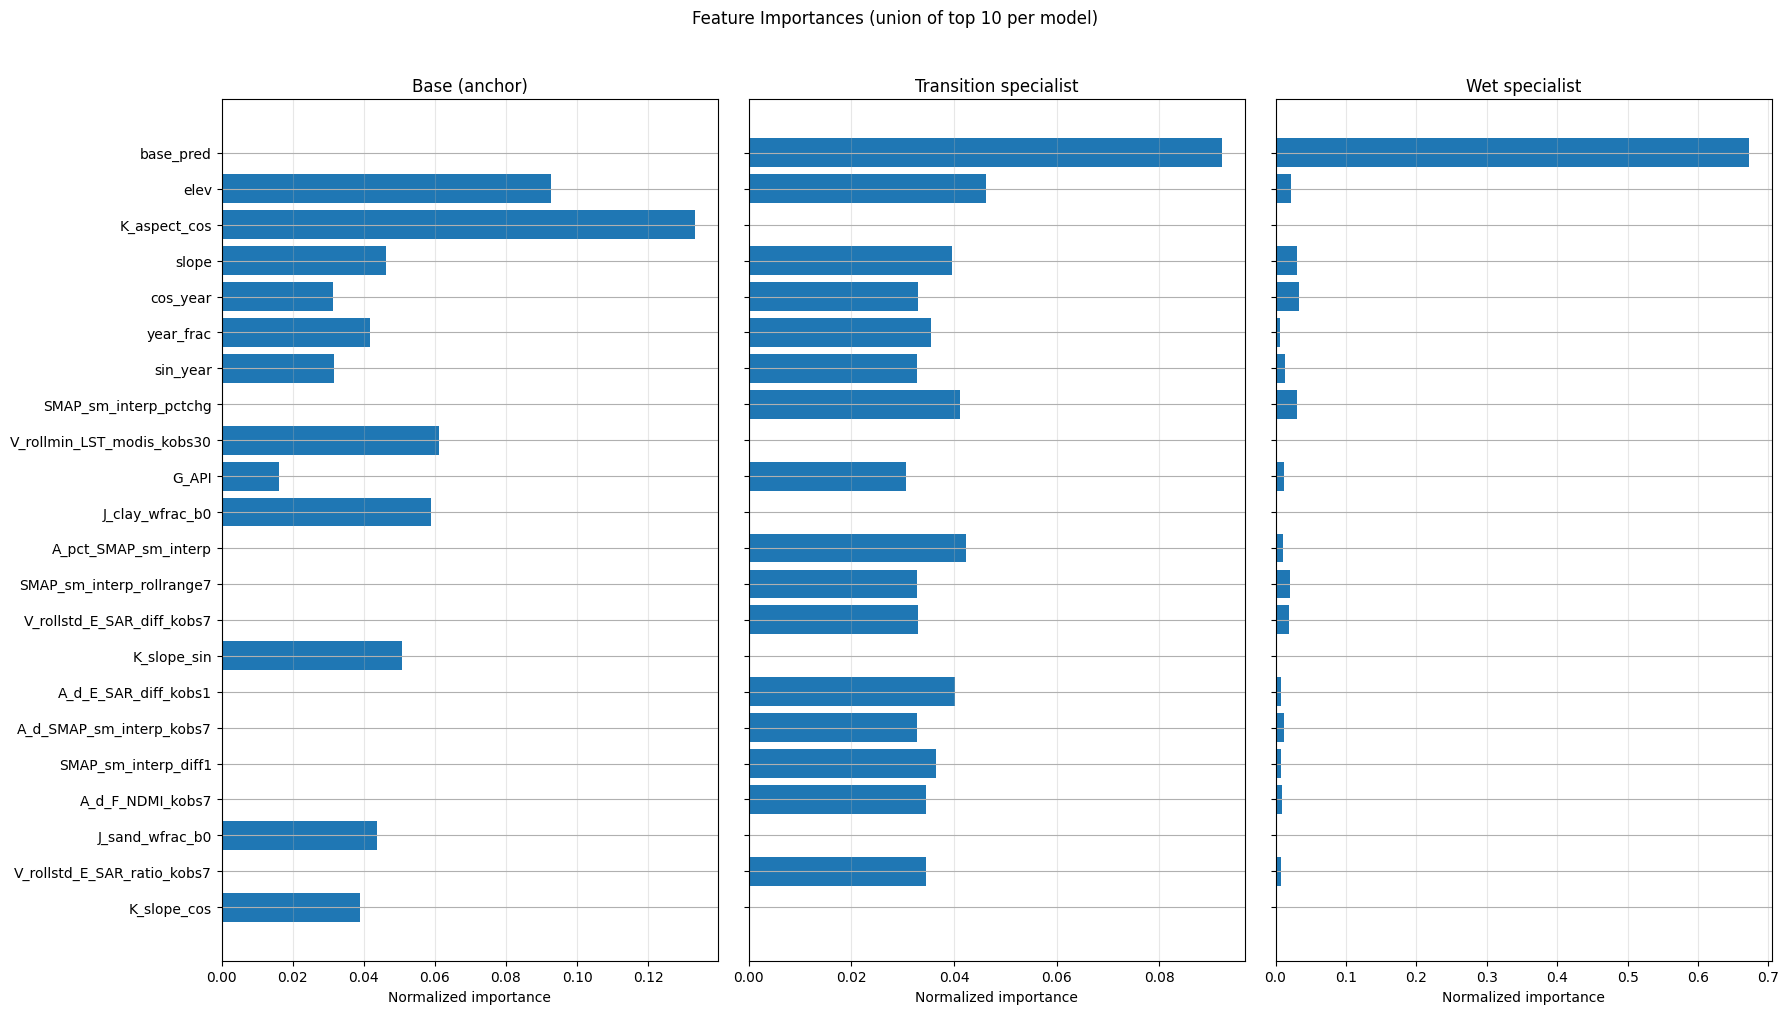

In [36]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 10

cols_base = list(FEATURE_COLS_BASE)
cols_aug = list(FEATURE_COLS_WET) + ["base_pred"]

imp_base = get_xgb_importance(xgb_dry, cols_base)
imp_trn  = get_xgb_importance(xgb_transition, cols_aug)
imp_wet  = get_xgb_importance(xgb_wet, cols_aug)

top_feats = sorted(set(
    imp_base.sort_values(ascending=False).head(TOP_K).index
) | set(
    imp_trn.sort_values(ascending=False).head(TOP_K).index
) | set(
    imp_wet.sort_values(ascending=False).head(TOP_K).index
))

cmp = pd.DataFrame({
    "base": imp_base.reindex(top_feats, fill_value=0.0),
    "transition": imp_trn.reindex(top_feats, fill_value=0.0),
    "wet": imp_wet.reindex(top_feats, fill_value=0.0),
})

cmp["mean"] = cmp[["base", "transition", "wet"]].mean(axis=1)
cmp = cmp.sort_values("mean", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, max(6, 0.45 * len(cmp))), sharey=True)

y = np.arange(len(cmp))

axes[0].barh(y, cmp["base"].values)
axes[0].set_title("Base (anchor)")
axes[0].set_xlabel("Normalized importance")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(y, cmp["transition"].values)
axes[1].set_title("Transition specialist")
axes[1].set_xlabel("Normalized importance")
axes[1].grid(axis="x", alpha=0.3)

axes[2].barh(y, cmp["wet"].values)
axes[2].set_title("Wet specialist")
axes[2].set_xlabel("Normalized importance")
axes[2].grid(axis="x", alpha=0.3)

axes[0].set_yticks(y)
axes[0].set_yticklabels(cmp.index)

plt.suptitle(f"Feature Importances (union of top {TOP_K} per model)", y=1.02)
plt.tight_layout()
plt.show()

### Residuals

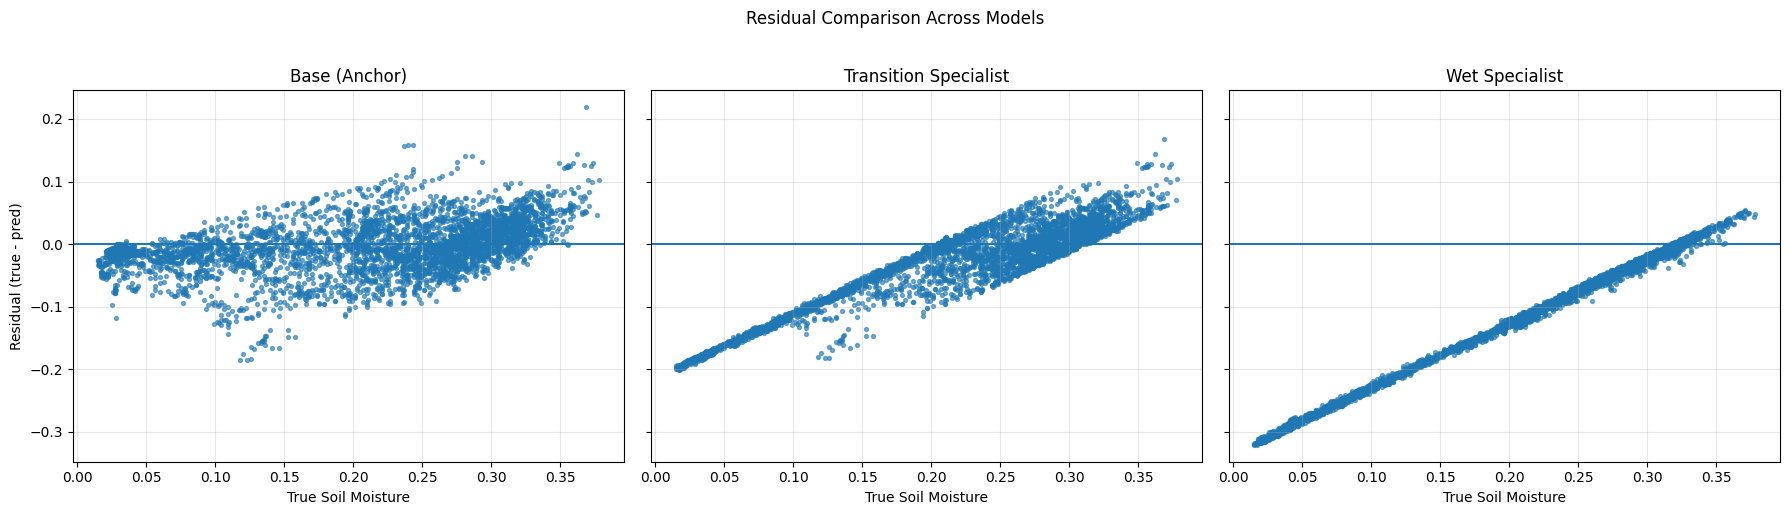

In [37]:
y_true = np.asarray(y_test).ravel()

pred_base = np.asarray(pred_dry_test).ravel()
pred_trn  = np.asarray(pred_transition).ravel()
pred_wet  = np.asarray(pred_wet).ravel()

res_base = y_true - pred_base
res_trn  = y_true - pred_trn
res_wet  = y_true - pred_wet

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(y_true, res_base, s=8, alpha=0.6)
axes[0].axhline(0)
axes[0].set_title("Base (Anchor)")
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_true, res_trn, s=8, alpha=0.6)
axes[1].axhline(0)
axes[1].set_title("Transition Specialist")
axes[1].set_xlabel("True Soil Moisture")
axes[1].grid(alpha=0.3)

axes[2].scatter(y_true, res_wet, s=8, alpha=0.6)
axes[2].axhline(0)
axes[2].set_title("Wet Specialist")
axes[2].set_xlabel("True Soil Moisture")
axes[2].grid(alpha=0.3)

plt.suptitle("Residual Comparison Across Models", y=1.02)
plt.tight_layout()
plt.show()

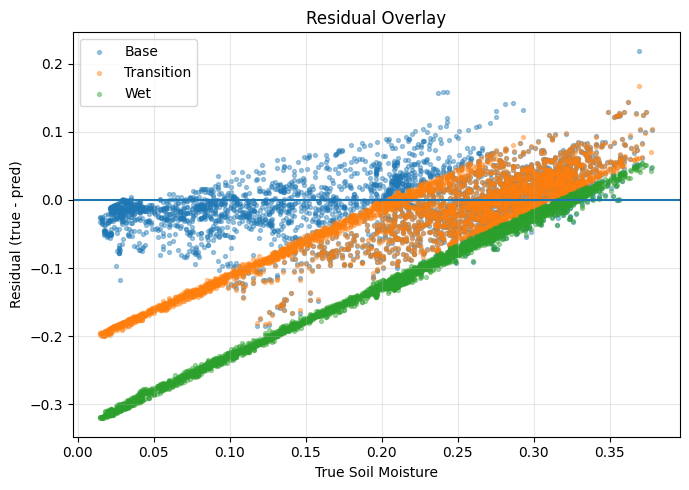

In [38]:
plt.figure(figsize=(7, 5))

plt.scatter(y_true, res_base, s=8, alpha=0.4, label="Base")
plt.scatter(y_true, res_trn,  s=8, alpha=0.4, label="Transition")
plt.scatter(y_true, res_wet,  s=8, alpha=0.4, label="Wet")

plt.axhline(0)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residual Overlay")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
metrics_dashboard(y_test, pred_dry_test, name="BASE (anchor) - global", return_dict=False)
metrics_dashboard(y_test, pred_transition, name="TRANSITION specialist - global", return_dict=False)
metrics_dashboard(y_test, pred_wet, name="WET specialist - global", return_dict=False)

In [39]:
y_test_arr = np.asarray(y_test).ravel()
pred_final = np.zeros_like(y_test_arr, dtype=float)
pred_final[mask_dry_test] = np.asarray(pred_dry_test).ravel()[mask_dry_test]
pred_final[mask_transition_test] = np.asarray(pred_transition).ravel()[mask_transition_test]
pred_final[mask_wet_test] = np.asarray(pred_wet).ravel()[mask_wet_test]

metrics_dashboard(y_test_arr, pred_final, name="FINAL | Hard Gated, Eval-Only", return_dict=False)

In [40]:
neat_print(get_metrics_dict(y_test_arr, pred_final, prefix=""), "FINAL | Hard Gated, Eval - Only")


FINAL | Hard Gated, Eval - Only
Metric                          Value
------------------------------------------
n                               4,016
r2                            0.85658
mae                           0.02581
rmse                          0.03566
ubrmse                        0.03453
bias                         -0.00893
med_ae                        0.01856
p90_ae                        0.05690
q05_err                      -0.07284
q50_err                      -0.00618
q95_err                       0.04339


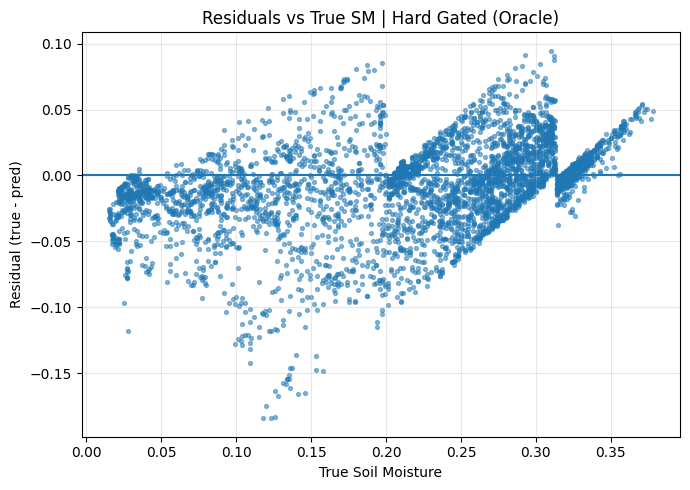

In [41]:
y_true = np.asarray(y_test_arr).ravel()
y_pred = np.asarray(pred_final).ravel()
residuals = y_true - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_true, residuals, s=8, alpha=0.5)
plt.axhline(0)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs True SM | Hard Gated (Oracle)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

In [45]:
import joblib

MODEL_PATH = "v20/v20.4/regime_classifier_xgb.json"
IMPUTER_PATH = "v20/v20.4/stable_classifier_imputer.pkl"  # The pickle file is not committed, please run v20.4.1 to generate it
COLS_PATH = "v20/v20.4/stable_classifier_cols.pkl"

clf = XGBClassifier()
clf.load_model(MODEL_PATH)

imputer = joblib.load(IMPUTER_PATH)
CLF_COLS = joblib.load(COLS_PATH)

print("Loaded classifier + imputer + CLF_COLS:", len(CLF_COLS))

Loaded classifier + imputer + CLF_COLS: 496


In [46]:

def clean_numeric_df(X):
    return X.replace([np.inf, -np.inf], np.nan)

X_clf_test = test_df[CLF_COLS].copy()
X_clf_test = clean_numeric_df(X_clf_test)

clip_q = 0.001
if clip_q:
    lo = pd.DataFrame(imputer.statistics_, index=CLF_COLS).T.iloc[0]
    lo_q = X_clf_test.quantile(clip_q, axis=0, numeric_only=True)
    hi_q = X_clf_test.quantile(1 - clip_q, axis=0, numeric_only=True)
    X_clf_test = X_clf_test.clip(lower=lo_q, upper=hi_q, axis=1)

X_clf_test_i = imputer.transform(X_clf_test)

In [47]:
proba_test = clf.predict_proba(X_clf_test_i)

p_stable = proba_test[:, 1]
stable_thresh = 0.60  # tune 0.55–0.70
is_stable = p_stable >= stable_thresh

print("Stable fraction (test):", float(is_stable.mean()))

Stable fraction (test): 0.8254482071713147


In [48]:
y_test_arr = np.asarray(y_test).ravel()

base_pred_test = np.asarray(pred_dry_test).ravel()
pred_transition_test = np.asarray(pred_transition).ravel()
pred_wet_test = np.asarray(pred_wet).ravel()

# Hard moisture gate using base prediction
mask_dry_hat = base_pred_test <= t1
mask_trans_hat = (base_pred_test > t1) & (base_pred_test <= t2)
mask_wet_hat = base_pred_test > t2

# Final prediction container
pred_final = np.zeros_like(base_pred_test, dtype=float)

# Dry and wet untouched
pred_final[mask_dry_hat] = base_pred_test[mask_dry_hat]
pred_final[mask_wet_hat] = pred_wet_test[mask_wet_hat]

# Transition band: classifier decides stable vs unstable
mask_trans_stable = mask_trans_hat & is_stable
mask_trans_unstable = mask_trans_hat & (~is_stable)

# If stable: use base (anchor). If unstable: use transition specialist
pred_final[mask_trans_stable] = base_pred_test[mask_trans_stable]
pred_final[mask_trans_unstable] = pred_transition_test[mask_trans_unstable]

metrics_dashboard(y_test_arr, pred_final, name=f"FINAL | Hard(Dry/Wet) + CLF(Transition stable>{stable_thresh})", return_dict=False)

In [49]:
print("Counts:")
print(" dry_hat:", int(mask_dry_hat.sum()))
print(" trans_hat:", int(mask_trans_hat.sum()))
print(" wet_hat:", int(mask_wet_hat.sum()))
print(" trans_stable:", int(mask_trans_stable.sum()))
print(" trans_unstable:", int(mask_trans_unstable.sum()))

Counts:
 dry_hat: 1524
 trans_hat: 2182
 wet_hat: 310
 trans_stable: 1673
 trans_unstable: 509


In [50]:
for thresh in [0.55, 0.60, 0.65, 0.70]:
    is_stable = p_stable >= thresh

    pred_tmp = np.zeros_like(base_pred_test)

    mask_trans_stable = mask_trans_hat & is_stable
    mask_trans_unstable = mask_trans_hat & (~is_stable)

    pred_tmp[mask_dry_hat] = base_pred_test[mask_dry_hat]
    pred_tmp[mask_wet_hat] = pred_wet_test[mask_wet_hat]
    pred_tmp[mask_trans_stable] = base_pred_test[mask_trans_stable]
    pred_tmp[mask_trans_unstable] = pred_transition_test[mask_trans_unstable]

    print("\nThreshold:", thresh)
    metrics_dashboard(y_test_arr, pred_tmp, name=f"thresh={thresh}", return_dict=False)


Threshold: 0.55



Threshold: 0.6



Threshold: 0.65



Threshold: 0.7


In [ ]:
alpha = 4.0  # try 2, 4, 6
w_unstable = 1.0 - p_stable
w = np.clip(w_unstable * alpha, 0.0, 1.0)

pred_final = np.zeros_like(base_pred_test, dtype=float)
pred_final[mask_dry_hat] = base_pred_test[mask_dry_hat]
pred_final[mask_wet_hat] = pred_wet_test[mask_wet_hat]

m = mask_trans_hat
pred_final[m] = (1.0 - w[m]) * base_pred_test[m] + w[m] * pred_transition_test[m]

metrics_dashboard(y_test_arr, pred_final, name=f"FINAL | Hard(Dry/Wet) + SoftBlend(Transition, alpha={alpha})", return_dict=False)

---

_Jakob Balkovec_

---

_Jakob Balkovec_

In [ ]:
# Export SHAP importance CSVs
summary = pd.DataFrame({name: r.reindex(all_feats, fill_value=0.0) for name, r in ranked.items()})
summary.index.name = "feature"
summary["mean"] = summary.mean(axis=1)
summary = summary.sort_values("mean", ascending=False)
summary.to_csv(f"{OUTPUT_ROOT}/regime_feature_importance_shap.csv")
print(f"Saved: regime_feature_importance_shap.csv  ({len(summary)} features)")

met_df.to_csv(f"{OUTPUT_ROOT}/regime_metrics.csv")
print("Saved: regime_metrics.csv")

In [51]:
# Cross-regime SHAP heatmap (union of all features across specialists)
all_feats = sorted(set().union(*[set(r.index) for r in ranked.values()]))

cmp_df = pd.DataFrame(
    {name: ranked[name].reindex(all_feats, fill_value=0.0) for name in ranked}
)
cmp_norm = cmp_df.div(cmp_df.max(axis=0), axis=1)
cmp_norm["_mean"] = cmp_norm.mean(axis=1)
cmp_norm = cmp_norm.sort_values("_mean", ascending=False).drop(columns="_mean")

n_feats = len(cmp_norm)
fig, ax = plt.subplots(figsize=(5, max(6, n_feats * 0.38)))

im = ax.imshow(cmp_norm.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(3))
ax.set_xticklabels(["Dry", "Transition", "Wet"], fontsize=12, fontweight="bold")
ax.set_yticks(range(n_feats))
ax.set_yticklabels(cmp_norm.index, fontsize=8)
ax.set_title(
    "Cross-Regime SHAP Importance\n(Normalized, union of all features)",
    fontsize=11, fontweight="bold", pad=10
)

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label("Normalized mean |SHAP|", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_ROOT}/regime_shap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: regime_shap_heatmap.png  ({n_feats} unique features)")

NameError: name 'ranked' is not defined

In [ ]:
# 3-panel SHAP bar chart — one panel per regime specialist
fig, axes = plt.subplots(1, 3, figsize=(20, max(6, max(len(r) for r in ranked.values()) * 0.42)))
fig.suptitle(
    "Feature Importance per Regime (SHAP mean |value|)\n"
    "Dry: base/anchor model  |  Transition & Wet: specialist models",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, (name, r) in zip(axes, ranked.items()):
    met = met_rows[name]
    r_plot = r.sort_values(ascending=True)

    ax.barh(
        r_plot.index, r_plot.values,
        color=REGIME_COLORS[name], alpha=0.85, edgecolor="white", linewidth=0.5
    )
    ax.set_title(f"{name} Regime", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Mean |SHAP value|", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    subtitle = (
        f"R²={met['r2']:+.3f}  "
        f"ubRMSE={met['ubrmse']:.4f}  "
        f"Bias={met['bias']:+.4f}"
    )
    ax.annotate(
        subtitle,
        xy=(0.5, -0.07), xycoords="axes fraction",
        ha="center", va="top", fontsize=8.5, color="#444444",
        bbox=dict(boxstyle="round,pad=0.3", fc="#f5f5f5", ec="#cccccc", lw=0.8)
    )

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{OUTPUT_ROOT}/regime_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: regime_shap_importance.png")

In [52]:
# All features ranked by mean |SHAP| per regime specialist
from IPython.display import display

ranked = {name: imp.sort_values(ascending=False) for name, imp in regime_shap_imps.items()}

for name, r in ranked.items():
    df_out = r.rename("Mean |SHAP|").reset_index()
    df_out.columns = ["Feature", "Mean |SHAP|"]
    df_out.index = range(1, len(df_out) + 1)
    df_out.index.name = "Rank"
    print(f"\n{'='*52}")
    print(f"  {name} Regime — {len(df_out)} Features Ranked")
    print(f"{'='*52}")
    display(
        df_out.style
        .bar(subset=["Mean |SHAP|"], color=REGIME_COLORS[name], width=80)
        .format("{:.5f}", subset=["Mean |SHAP|"])
    )

NameError: name 'regime_shap_imps' is not defined

In [ ]:
# Metrics per regime using existing test predictions
REGIME_COLORS = {"Dry": "#c8934f", "Transition": "#5aaa6e", "Wet": "#4f82c8"}

slices = {
    "Dry":        (y_test_arr[mask_dry_test],        np.asarray(pred_dry_test).ravel()[mask_dry_test]),
    "Transition": (y_test_arr[mask_transition_test], np.asarray(pred_transition).ravel()[mask_transition_test]),
    "Wet":        (y_test_arr[mask_wet_test],        np.asarray(pred_wet).ravel()[mask_wet_test]),
}

met_rows = {}
for name, (yt, yp) in slices.items():
    m = get_metrics_dict(yt, yp, prefix="")
    met_rows[name] = {k: m[k] for k in ["n", "r2", "rmse", "ubrmse", "bias"]}
    print(f"{name:12s}: R²={m['r2']:+.4f}  RMSE={m['rmse']:.4f}  "
          f"ubRMSE={m['ubrmse']:.4f}  Bias={m['bias']:+.4f}")

met_df = pd.DataFrame(met_rows).T
met_df.index.name = "Regime"
met_df.columns = ["n", "R²", "RMSE", "ubRMSE", "Bias"]
met_df["n"] = met_df["n"].astype(int)

display(
    met_df.style
    .format({"n": "{:,}", "R²": "{:.4f}", "RMSE": "{:.4f}", "ubRMSE": "{:.4f}", "Bias": "{:+.4f}"})
    .background_gradient(subset=["R²"], cmap="Greens")
    .background_gradient(subset=["RMSE", "ubRMSE"], cmap="Reds_r")
    .set_caption("Test-set regime metrics — regime specialists")
)

In [ ]:
import shap
shap.initjs()

# Feature name lists matching each model's training data
dry_feat_names  = list(FEATURE_COLS_BASE)
spec_feat_names = list(FEATURE_COLS_WET) + ["base_pred"]

# Test-set slices per regime (same masks from cell above)
X_dry_shap   = X_test_base.to_numpy()[mask_dry_test]
X_trans_shap = X_test_aug[mask_transition_test]
X_wet_shap   = X_test_aug[mask_wet_test]

print(f"SHAP sample counts — Dry: {len(X_dry_shap):,}  "
      f"Transition: {len(X_trans_shap):,}  Wet: {len(X_wet_shap):,}")

# Compute SHAP values using each specialist
sv_dry  = shap.TreeExplainer(xgb_dry).shap_values(X_dry_shap)
sv_trn  = shap.TreeExplainer(xgb_transition).shap_values(X_trans_shap)
sv_wet  = shap.TreeExplainer(xgb_wet).shap_values(X_wet_shap)

imp_dry = pd.Series(np.abs(sv_dry).mean(axis=0),  index=dry_feat_names,  name="Dry")
imp_trn = pd.Series(np.abs(sv_trn).mean(axis=0),  index=spec_feat_names, name="Transition")
imp_wet = pd.Series(np.abs(sv_wet).mean(axis=0),  index=spec_feat_names, name="Wet")

regime_shap_imps = {"Dry": imp_dry, "Transition": imp_trn, "Wet": imp_wet}
print("SHAP importance computed.")

---

## Feature Importance — SHAP per Regime

Uses the already-trained regime specialists (`xgb_dry`, `xgb_transition`, `xgb_wet`) to compute SHAP mean |values| on the test-set slice for each regime. Metrics (R², RMSE, ubRMSE, Bias) are pulled from the same test predictions computed above.